# Plotting with Python

This script will plot the results of all groups data AND the computer generated data.

- Computer generated data is in `automated` directory
- will need to upload all students csv files
- update number of groups if it's not 10

## [Binder link to this notebook](https://mybinder.org/v2/gh/heattard/NU-Camp-2026/HEAD)

### The first thing we always need to do is import *packages* that we will use.  

Run the below block of code by selecting the code block and hitting "shift + enter."  This will read in the packages.  

In [3]:
import pandas as pd #pandas gives an helpful way to deal with two-dimensional data (columns and rows)
import numpy as np #this has more math options
import matplotlib.pyplot as plt #plotting.  Based on MATLAB

total_groups = 10

In [4]:
df_comp = pd.read_csv('/automated/summary NTT Data from idTracker.csv') # read in the data
df_comp #print the data

,segment,start_time_sec,end_time_sec,top_time,middle_time,bottom_time,top_transitions,bottom_transitions,avg_bottom_dist
0,1,0,30,1.100000,1.650000,27.233333,1,0,2.371724
1,2,30,60,6.800000,11.383333,11.816667,4,6,4.990491
2,3,60,90,7.616667,15.000000,7.383333,6,4,5.516379
3,4,90,120,5.966667,13.383333,10.650000,6,10,4.850978
4,5,120,150,9.733333,14.800000,5.466667,7,5,5.906044
5,6,150,180,13.316667,11.150000,5.533333,7,4,6.355105


In [5]:
groups = np.arange(1,total_groups+1,1) #+1 b/c arange is not inclusive
minutes = 3.0
file_name = '_20260804_NTT-Scoring.csv' #/content/01_20260804_NTT-Scoring.xlsx

## Loop through each csv for each group
- Find the amount of time in each location and put it in a new array
- average it
- plot each one AND the autmoted one

[0.5 1.  1.5 2.  2.5 3. ]
/content/01_20260804_NTT-Scoring.csv
/content/02_20260804_NTT-Scoring.csv


Text(0.5, 0.66, 'All Groups Data')

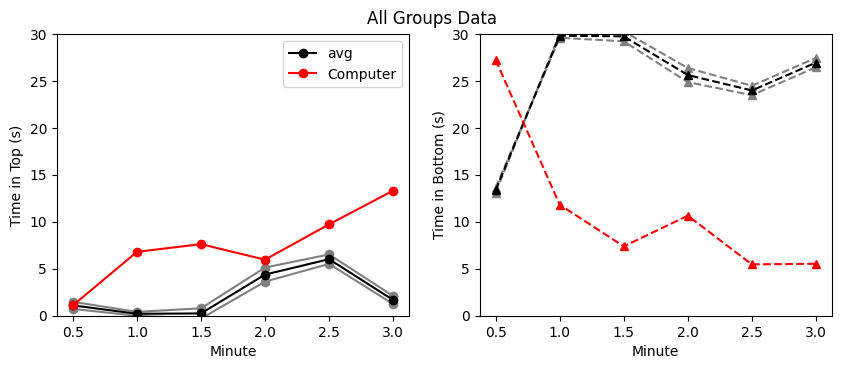

In [34]:
second_interval = 30
total_mins = 3.0

seconds = np.arange(0,total_mins*60,second_interval) #array of bins in seconds
minutes = np.arange(0,total_mins,second_interval/60) # make a list of times from 0 to total_mins; +1 b/c not inclusive

all_top = np.full([len(groups),len(minutes)],np.nan) #empty array of missing values
all_bottom = np.copy(all_top)

x_axis = minutes + (second_interval/60) #the x-axis labels will start at the second interval
print(x_axis)
marks = ['o','^']
lines = ['solid','dashed']

fig, axs = plt.subplots(1,2,subplot_kw=dict(box_aspect=0.8),figsize=(10, 10)) #the same number of plots as there are fish

for g,group in enumerate(groups):
  df = pd.read_csv(f'/content/{group:02}{file_name}') # read in the data
  #print(f'/content/{group:02}{file_name}')
  df['Top_time_delta'] = df['Top Region Exit']-df['Top Region Entry']
  df['Bottom_time_delta'] = df['Bottom Region Exit']-df['Bottom Region Entry']

  bins = np.zeros(len(minutes)) #this will hold the data for each minute for the top

  for i,u in enumerate(['Top','Bottom']): #loop through each fish.  u will be the fish ID, i will be a counter starting at 0
  ##############
  ##### This is all getting the data
  #####################

    for j,t in enumerate(seconds): #loop through each interval bin to get data for it
      #print(f'on {u} and {t}')
      bins[j] = bins[j] + np.round(df[(df[f'{u} Region Entry'] >= t) & (df[f'{u} Region Exit'] < t+second_interval)][f'{u}_time_delta'].sum(),2)
      #print(bins)
      for l in range(len(df)):
        if (df[f'{u} Region Entry'].iloc[l] < t + second_interval ) and (df[f'{u} Region Exit'].iloc[l] > t + second_interval): #it crosses the bin boundary

          if (t > df[f'{u} Region Entry'].iloc[l] ): #check if the starting time is ALSO between these times:
            bins[j] = np.round(bins[j] + ( (t+second_interval) - t),2)
            print(f'new total: {bins[j]}')
          else:
            bins[j] = np.round(bins[j] + ( (t+second_interval) - df[f'{u} Region Entry'].iloc[l]),2)
            if df[f'{u} Region Exit'].iloc[l] > t+(second_interval*2):
              print('in if')
              continue
            else:
              bins[j+1] = np.round(bins[j+1] + np.abs((t+second_interval) - df[f'{u} Region Exit'].iloc[l]),2)

    #######################
    ####This is the plotting
    ##### The code makes one plot but puts two lines on the plot, one for when the fish are in the top and one for them in the bottom
    ##################
    if u == 'Top':
      all_top[g,:] = bins
    if u == 'Bottom':
      all_bottom[g,:] = bins
    #print(bins)
    axs[i].plot(x_axis,bins,marker=marks[i],linestyle=lines[i],color='grey')
    bins = np.zeros(len(minutes))

all_top_avg = np.mean(all_top,0)
all_bottom_avg = np.mean(all_bottom,0)
axs[0].plot(x_axis,all_top_avg,marker=marks[0],linestyle=lines[0],color='black',label='avg')
axs[1].plot(x_axis,all_bottom_avg,marker=marks[1],linestyle=lines[1],color='black')

axs[0].plot(x_axis,df_comp['top_time'],marker=marks[0],linestyle=lines[0],color='red',label='Computer')
axs[1].plot(x_axis,df_comp['bottom_time'],marker=marks[1],linestyle=lines[1],color='red')

#########
###Now we are out of the loop and making the plot prettier
################
#plt.title(f'All groups')
axs[0].set_ylim([0, 30])
axs[1].set_ylim([0, 30])
axs[0].title('Time in top')
axs[0].legend()
axs[0].set_xlabel("Minute") #label the x axis
axs[0].set_ylabel("Time in Top (s)")

axs[1].set_xlabel("Minute") #label the x axis
axs[1].set_ylabel("Time in Bottom (s)")
axs[1].title('Time in Bottom')
fig.suptitle("All Groups Data",y=0.66)